# Data Preprocessing

## 1. Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("Employee.xlsx")
display(df.head())
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nStatistical analysis:")
display(df.describe(include="all").T)

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


Shape: (148, 6)

Data types:
Company     object
Age        float64
Salary     float64
Place       object
Country     object
Gender       int64
dtype: object

Statistical analysis:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Company,140,6,TCS,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,130.0,NaN,NaN,NaN,30.484615,11.09664,0.0,22.0,32.5,37.75,54.0
Salary,124.0,NaN,NaN,NaN,5312.467742,2573.764683,1089.0,3030.0,5000.0,8000.0,9876.0
Place,134,11,Mumbai,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,148,1,India,148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,148.0,NaN,NaN,NaN,0.222973,0.417654,0.0,0.0,0.0,0.0,1.0


In [2]:
for column in df.columns:
    unique_values = df[column].dropna().unique()
    print(f"\n{column}")
    print("Unique values:", unique_values)
    print("Length:", len(unique_values))


Company
Unique values: ['TCS' 'Infosys' 'CTS' 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Length: 6

Age
Unique values: [20. 30. 35. 40. 23. 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41. 24.
 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Length: 29

Salary
Unique values: [2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030. 3045.
 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934. 4034.
 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787. 3454.
 5654. 5009. 5098. 3033.]
Length: 40

Place
Unique values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Length: 11

Country
Unique values: ['India']
Length: 1

Gender
Unique values: [0 1]
Length: 2


In [3]:
rename_map = {'Company': 'company', 'Age': 'age', 'Salary': 'salary', 'Place': 'place', 'Country': 'country', 'Gender': 'gender'}
df.rename(columns=rename_map, inplace=True)
print("Renamed columns:", df.columns.tolist())

Renamed columns: ['company', 'age', 'salary', 'place', 'country', 'gender']


## 2. Data Cleaning

In [4]:
print("Missing values:")
display(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nZero values:")
for column in df.select_dtypes(include=np.number).columns:
    print(column, ":", int((df[column] == 0).sum()))

Missing values:


company     8
age        18
salary     24
place      14
country     0
gender      0
dtype: int64


Duplicate rows: 4

Zero values:
age : 6
salary : 0
gender : 115


In [5]:
if "age" in df.columns:
    df.loc[df["age"] == 0, "age"] = np.nan

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

for column in df.columns:
    if df[column].isnull().any():
        if pd.api.types.is_numeric_dtype(df[column]):
            df[column] = df[column].fillna(df[column].median())
        else:
            mode = df[column].mode()
            if not mode.empty:
                df[column] = df[column].fillna(mode.iloc[0])

print("Missing values after treatment:")
display(df.isnull().sum())
print("Duplicate rows after removal:", df.duplicated().sum())

Missing values after treatment:


company    0
age        0
salary     0
place      0
country    0
gender     0
dtype: int64

Duplicate rows after removal: 0


In [6]:
outlier_results = {}

for column in df.select_dtypes(include=np.number).columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[column] < lower) | (df[column] > upper)).sum()

    outlier_results[column] = {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": int(count)
    }

display(pd.DataFrame(outlier_results).T)

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
age,23.75,36.0,12.25,5.375,54.375,0.0
salary,3045.00,7084.0,4039.00,-3013.500,13142.500,0.0
gender,0.00,0.0,0.00,0.000,0.000,32.0


## 3. Data Analysis

,company,age,salary,place,country,gender
21,Infosys,50.0,3184.0,Delhi,India,0
32,Infosys,45.0,4034.0,Calcutta,India,0
39,Infosys,41.0,3000.0,Mumbai,India,0
50,Infosys,41.0,3000.0,Chennai,India,0
57,Infosys,51.0,3184.0,Hyderabad,India,0
68,Infosys,43.0,4034.0,Mumbai,India,0
75,Infosys,44.0,3000.0,Cochin,India,0
85,Infosys,41.0,3000.0,Delhi,India,0
92,Infosys,54.0,3184.0,Mumbai,India,0
103,Infosys,44.0,4034.0,Delhi,India,0


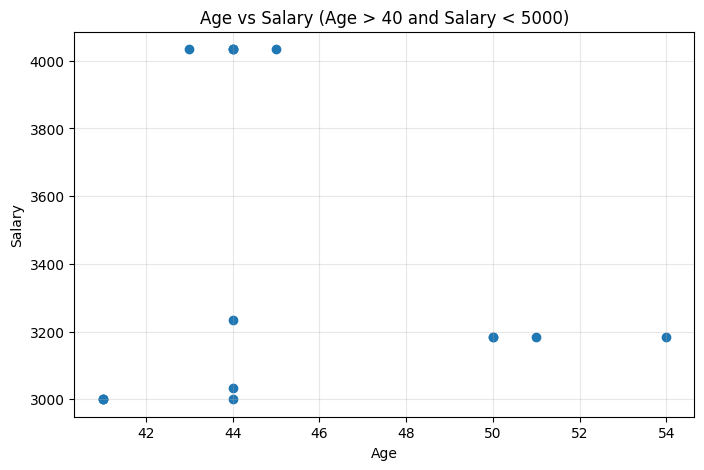

In [7]:
filtered_df = df[(df["age"] > 40) & (df["salary"] < 5000)]
display(filtered_df)

plt.figure(figsize=(8, 5))
plt.scatter(filtered_df["age"], filtered_df["salary"])
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary (Age > 40 and Salary < 5000)")
plt.grid(True, alpha=0.3)
plt.show()

,Number of People
place,
Mumbai,48
Calcutta,32
Chennai,14
Delhi,14
Cochin,13
Noida,8
Hyderabad,8
Podicherry,3
Pune,2


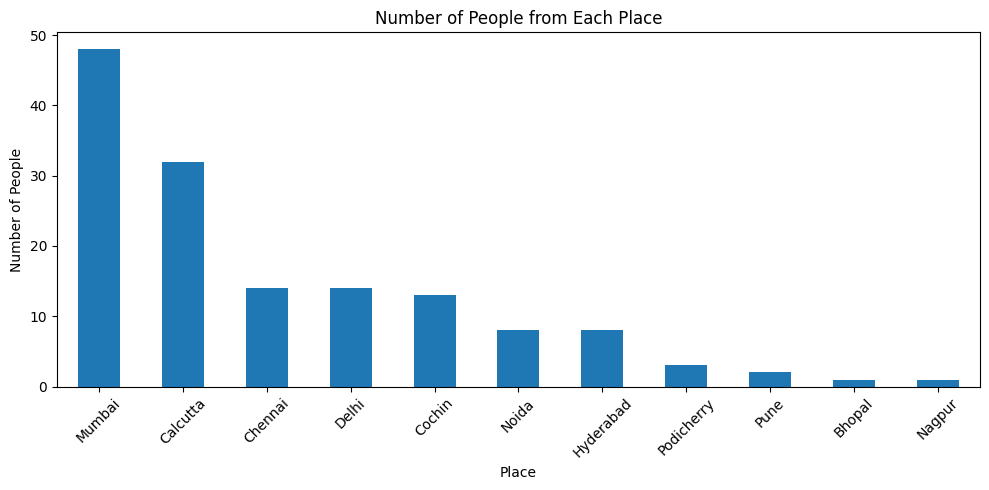

In [8]:
place_column = 'place'

if place_column:
    place_counts = df[place_column].value_counts()
    display(place_counts.to_frame("Number of People"))

    plt.figure(figsize=(10, 5))
    place_counts.plot(kind="bar")
    plt.xlabel("Place")
    plt.ylabel("Number of People")
    plt.title("Number of People from Each Place")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No place/location/city column was identified.")

## 4. Data Encoding

In [9]:
categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Categorical columns:", categorical_columns)

encoded_df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=False,
    dtype=int
)

display(encoded_df.head())

Categorical columns: ['company', 'place', 'country']


,age,salary,gender,company_CTS,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services,place_Bhopal,place_Calcutta,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune,country_India
0,20.0,5000.0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1
1,30.0,5000.0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
2,35.0,2300.0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1
3,40.0,3000.0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
4,23.0,4000.0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1


## 5. Feature Scaling

In [10]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

numeric_columns = encoded_df.select_dtypes(include=np.number).columns

standard_scaled_df = pd.DataFrame(
    StandardScaler().fit_transform(encoded_df[numeric_columns]),
    columns=numeric_columns
)

print("StandardScaler:")
display(standard_scaled_df.head())

minmax_scaled_df = pd.DataFrame(
    MinMaxScaler().fit_transform(encoded_df[numeric_columns]),
    columns=numeric_columns
)

print("MinMaxScaler:")
display(minmax_scaled_df.head())

StandardScaler:


,age,salary,gender,company_CTS,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services,place_Bhopal,place_Calcutta,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune,country_India
0,-1.484676,-0.100827,-0.534522,-0.566658,-0.118678,-0.652490,-0.118678,1.183216,-0.118678,-0.083624,-0.534522,3.047247,-0.315018,-0.328165,-0.242536,-0.707107,-0.083624,-0.242536,-0.145865,-0.118678,0.0
1,-0.267174,-0.100827,-0.534522,-0.566658,-0.118678,1.532592,-0.118678,-0.845154,-0.118678,-0.083624,-0.534522,-0.328165,-0.315018,-0.328165,-0.242536,1.414214,-0.083624,-0.242536,-0.145865,-0.118678,0.0
2,0.341577,-1.243735,-0.534522,-0.566658,-0.118678,-0.652490,-0.118678,1.183216,-0.118678,-0.083624,1.870829,-0.328165,-0.315018,-0.328165,-0.242536,-0.707107,-0.083624,-0.242536,-0.145865,-0.118678,0.0
3,0.950328,-0.947426,-0.534522,-0.566658,-0.118678,1.532592,-0.118678,-0.845154,-0.118678,-0.083624,-0.534522,-0.328165,-0.315018,3.047247,-0.242536,-0.707107,-0.083624,-0.242536,-0.145865,-0.118678,0.0
4,-1.119426,-0.524127,-0.534522,-0.566658,-0.118678,-0.652490,-0.118678,1.183216,-0.118678,-0.083624,-0.534522,-0.328165,-0.315018,-0.328165,-0.242536,1.414214,-0.083624,-0.242536,-0.145865,-0.118678,0.0


MinMaxScaler:


,age,salary,gender,company_CTS,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services,place_Bhopal,place_Calcutta,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune,country_India
0,0.081081,0.445089,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.351351,0.445089,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.486486,0.137817,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.621622,0.217480,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.162162,0.331285,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
